### Urban heat island modeling

The Urban Heat Island (UHI) effect is the long-observed phenomenon of heightened localized temperatures due to humanity’s urban built environments. It is, more specifically, the result of a number of physical processes that are more frequently at play in an urban environment. These include an environment’s thermal storage capacity, anthropogenic heat, horizontal advection of heat, aerosol concentration, and the geometry of large buildings. 

This notebook focuses primarily on thermal storage capacity, with some parameter variation to model basic differences in surface reflectivity, surface roughness, evapotranspiration, etc. The focus of the model will be on the daily (24-hr) solar radiation cycle. To do so, I setup a 1-dimensional diffusion equation:

$ \frac{\partial T(z,t)}{\partial t}=\eta\frac{\partial^2T(z,t)}{\partial z^2} $

that models the diffusion of heat $T(z,t)$ into the surface (at depth $z$) over time ($t$) given a thermal diffusivity of $\eta$. To introduce the other factors at play into the model, the surface boundary condition of the diffusion equation will come from the Energy Balance equation:
$ R_{\text{net}}+A=H+LE+G $

that describes how the sum of net radiation $R_{\text{net}}$ and anthropogenic heat $A$ is equal to the sum of sensible heat flux $H$, latent heat flux $LE$, and ground heat flux $G$. Using the ground heat flux $G$ as the surface boundary condition of the diffusion equation:

$ G=-k\left(\left.\frac{\partial T(z,t)}{\partial z}\right)\right|_{z=0} $

given thermal conductivity $k$, allows for those additional parameters to contribute to the model. Specifically, these parameters include:
$ R_{\text{net}}=SW+LW $
$ R_{\text{net}}=(1-\alpha)SW_{\text{down}}-\sigma \left((T_{\text{surface}})^4-(T_{air})^4\right) $

where $SW $ is shortwave radiation, $LW $ is longwave radiation, $\alpha $ is albedo, $SW_{\text{down}}$ is incoming solar radiation, $\sigma$ is the Stefan-Boltzmann constant, and $T$ is temperature. Other parameters include:

$ H=\rho_{\text{air}}*c_p*C_H*u*(T_{\text{surface}}-T_{\text{air}}) $
where $\rho_{\text{air}}$ is air density, $c_p$ is the specific heat of air, $C_H$ is the bulk heat transfer coefficient, and $u $ is wind speed.

$ LE=f*R_{\text{net}} $
where $f$ is an evaporative fraction. Many of these parameters are not particularly important to this specific comparison between urban and rural settings or can be generalized based on existing research and will thus be estimated for the sake of simplicity (feel free to email me to read my full report!)

### Starting simple
A steady-state solution to the diffusion equation in which we set the $\frac{\partial T}{ \partial t}$ term to 0, assuming some constant surface temperature $T_{\text{surface}}$ and temperature at depth $T_{\text{depth}}$, is:
$ T(z)=T_{\text{surface}}+(T_{\text{depth}}-T_{\text{surface}}) * \frac{z}{d} $
given a total depth of $d$. This just assumes a linear relationship between depth and temperature.

Let's code this up and see how it looks!

In [1]:
# library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# this setup step allows for pdf-embedded fonts, readable in adobe illustrator!
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
# setting up surface and depth temperatures of 10 and 20 degrees, respectively
ss_surf_temp = 10
ss_depth_temp = 20

# depth (in meters)
ss_depth = 5

# this is the steady state function, accepting depth z and returning the temperature!
def ss_T_z(z):
    return ss_surf_temp + ((ss_depth_temp - ss_surf_temp) * (z / ss_depth))

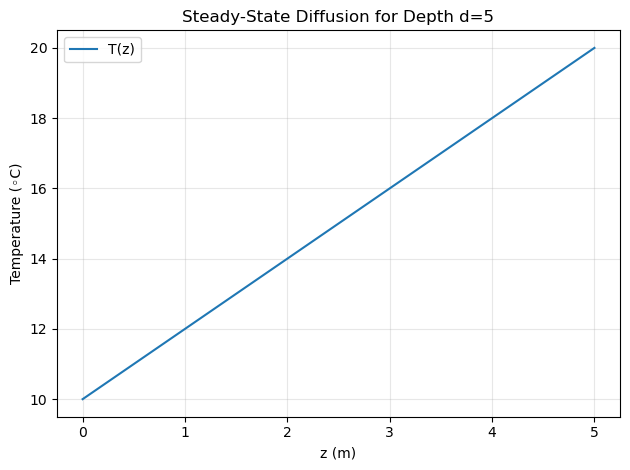

In [3]:
# visualize the function with matplotlib
fig, ax = plt.subplots()
ss_z = np.linspace(0.,5.,100,endpoint=True)
ss_temp = [ss_T_z(z) for z in ss_z]
ax.plot(ss_z, ss_temp, label='T(z)')
ax.set_title('Steady-State Diffusion for Depth d=5')
ax.set_xlabel('z (m)')
ax.set_ylabel('Temperature (◦C)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
# use this line to save a pdf version, editable in illustrator!
# plt.savefig("steady_state.pdf",transparent=True)
plt.show()

The steady state solution, as expected, is a pretty uninteresting solution. We know that the temperature will not diffuse linearly, and we have no way of modifying this equation to include all the interesting parameter differences that end up causing urban heat islands.

Now, solving the equation analytically is a bit trickier. Because the effect being studied here is a daily solar radiation cycle, the forcing term we're looking at is essentially a sinusoidal function dependent on time, where the sinusoid is then dampened inside the surface. Not having all that much experience in this field, I'll instead rely on an established solution for this kind of problem published by Carslaw & Jaeger in 1959:

$ T(z,t)=T_{\text{avg}}+A_0\text{exp}\left(-z\sqrt{\frac{\omega}{2\eta}}\right)\text{sin}\left(\omega t-z\sqrt{\frac{\omega}{2\eta}}\right) $

where $T_{\text{avg}}$ is the mean temperature the function oscillates around, $A_0$ is the amplitude of the oscillation at the surface, $\omega$ is the frequency of oscillation. and $\eta$ is the thermal diffusivity coefficient. Let's now try coding this version up!

In [4]:
# rather than setting temps at the surface and at depth, we set the mean and amplitude
cj_T_avg = 15 # degrees C
cj_A_0 = 7 # degrees C
cj_omega = 7e-5 # gives us a daily oscillation
cj_eta = 3e-7 # thermal diffusivity coefficient

# this is the carslaw-jaeger function, accepting depth AND time and returning temperature
def cj_T_z(z,t):
    expterm = np.exp(-1 * z * np.sqrt(cj_omega / (2*cj_eta)))
    sinterm = np.sin((cj_omega * t) - (z * np.sqrt(cj_omega / (2*cj_eta))))
    return cj_T_avg + (cj_A_0 * expterm * sinterm)

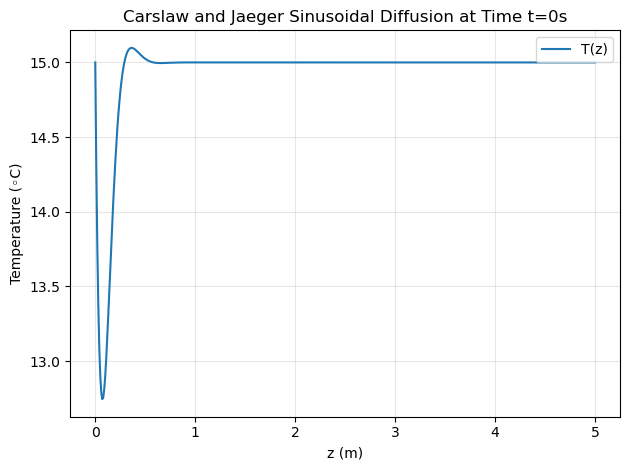

In [13]:
# let's now visualize this as well
fig, ax = plt.subplots()
cj_z = np.linspace(0.,5.,500,endpoint=True)

# mess around with this value to see the result at different times!
cj_time = 0
cj_temp = [cj_T_z(z,cj_time) for z in cj_z]
ax.plot(cj_z, cj_temp, label='T(z)')
ax.set_title(f'Carslaw and Jaeger Sinusoidal Diffusion at Time t={cj_time}s')
ax.set_xlabel('z (m)')
ax.set_ylabel('Temperature (◦C)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
# plt.savefig("finalproj/carslaw_jaeger.pdf",transparent=True)
plt.show()

This looks quite a bit more interesting! The temperature oscillation decays quickly (exponentially) with depth, penetrating approximately half a meter before becoming pretty much negligible at this scale. Messing with the time shows how this solution more accurately captures the way heat will be stored in a surface and look wavelike given a solar radiation cycle. Still, we only have a few parameters to mess with here, and none let us differentiate between urban and rural environments. 

To do this solution, I'm discretizing the diffusion equation using a Crank-Nicolson or semi-implicit method with mixed boundary conditions. The surface boundary will be a Neumann condition and will use the ground heat flux calculated from our energy balance equation, while the depth boundary will be a Dirichlet constant. If you're interested in the full solution, feel free to email me!

In [15]:
# I'll first setup a daily solar radiation forcing function that's a bit customizable:
def sinusoid_surface_temp(t, T_avg, amp, omega):
    return T_avg + (amp * np.sin(omega * t))

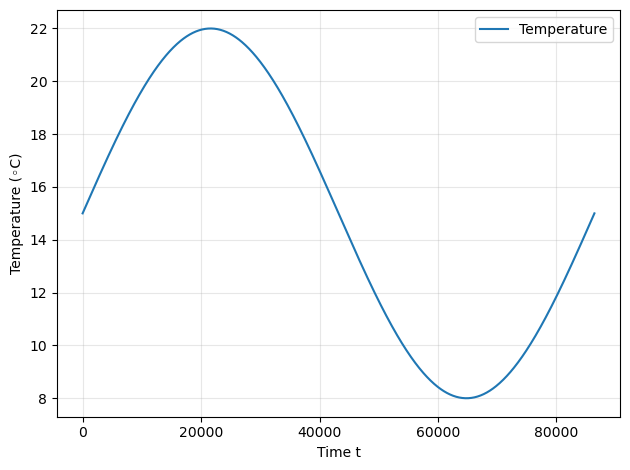

In [17]:
# visualizing the temperature forcing
fig, ax = plt.subplots()
sin_t = np.linspace(0.,86400.,1000,endpoint=True)
sin_temp = [sinusoid_surface_temp(t, 15, 7, 2 * np.pi / 86400) for t in sin_t]
ax.plot(sin_t, sin_temp, label='Temperature')
ax.set_title(f'')
ax.set_xlabel('Time t')
ax.set_ylabel('Temperature (◦C)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
# plt.savefig("finalproj/sinusoid_forcing.pdf",transparent=True)
plt.show()

In [18]:
# Here's a first go at the Crank-Nicolson solution, this time slightly modified to accept a Dirichlet boundary at the surface.
# Doing this allows me to test that the Crank-Nicolson solution functions pretty much correctly by using the same forcing function on both.

# I also use the Thomas algorithm to do a much more efficient solution of our tridiagonal system
# (https://sites.lsa.umich.edu/shixumeng/wp-content/uploads/sites/629/2020/02/Thomas.pdf for more info!)

def thomas(d, a, b, y):
    N = len(d)
    x = [0] * N
    a_p = []
    y_dp = []
    
    for i in range(N):
        if i == 0:
            a_p.append(a[i] / d[i])
            y_dp.append(y[i] / d[i])
        else:
            denom = d[i] - b[i] * a_p[i-1]
            a_p.append(a[i] / denom)
            y_dp.append((y[i] - b[i] * y_dp[i-1]) / denom)
    
    for i in range(N-1, -1, -1):
        if i == N-1:
            x[i] = y_dp[i]
        else:
            x[i] = y_dp[i] - a_p[i] * x[i+1]
    
    return x

def crank_nicolson_prescribed_surface(D, dz, init_profile, depth_value, surface_temps, total_timesteps):
    N_total = len(init_profile) 
    N = N_total - 2 

    A_d = [1 + D] * N  
    A_a = [-D/2] * (N-1) + [0] 
    A_b = [0] + [-D/2] * (N-1) 
        
    T_history = [list(init_profile)]
    T_current = list(init_profile)
    
    for t in range(total_timesteps):
        T_surface = surface_temps[t]
        T_bottom = depth_value
        
        rhs = [0] * N
        for i in range(N):
            j = i + 1 
            rhs[i] = T_current[j] * (1 - D)
            if j > 1:  
                rhs[i] += (D/2) * T_current[j-1] 
            if j < N_total - 2:  
                rhs[i] += (D/2) * T_current[j+1] 
            if j == 1:  
                rhs[i] += (D/2) * T_current[0] 
                rhs[i] += (D/2) * T_surface    
            if j == N_total - 2:  
                rhs[i] += (D/2) * T_bottom 
                rhs[i] += (D/2) * T_bottom 
        T_interior = thomas(A_d, A_a, A_b, rhs)
        
        T_new = [T_surface] + T_interior + [T_bottom]
        
        T_current = T_new
        T_history.append(T_new)
    
    return T_history


dt = 1080  # seconds 
dz = 0.02  # m
eta = 3e-7  # m^2/s
D = (eta * dt) / (dz**2)

print(f"D = {D:.4f}")

total_time = 86400 * 3 
total_depth = 1.0 
N_total = int(total_depth / dz) + 1  
z = np.linspace(0, total_depth, N_total)

# Time array
time_array = np.arange(0, total_time, dt)
n_timesteps = len(time_array)

forced_surface = [sinusoid_surface_temp(t, 15, 7, 7e-5) for t in time_array]

# start at mean temperature everywhere
init_condition = [15.0] * N_total

T_history = crank_nicolson_prescribed_surface(
    D, dz, init_condition, 15.0, forced_surface, n_timesteps
)

T_history = np.array(T_history)

D = 0.8100


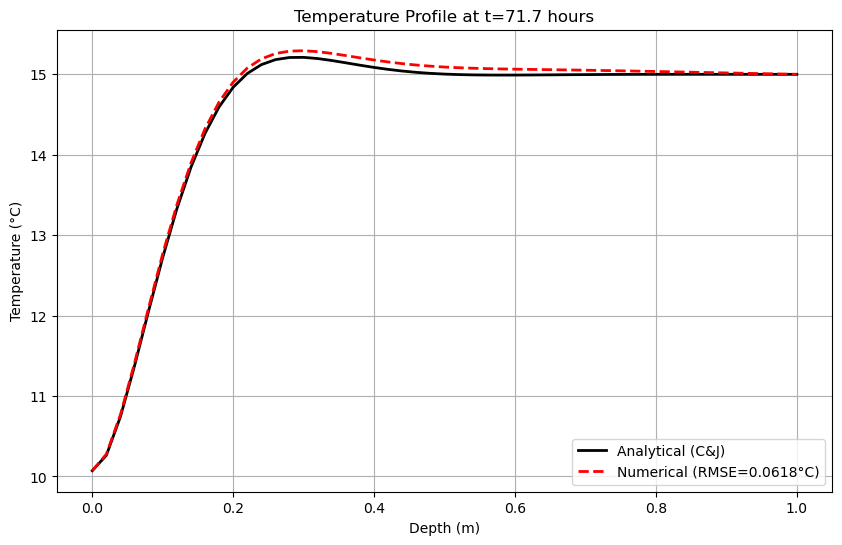

RMSE: 0.0618 °C


In [20]:
# Compare with Carslaw & Jaeger at final time
def carslaw_jaeger(z, t, T_mean, A0, omega, eta):
    decay = np.exp(-z * np.sqrt(omega / (2 * eta)))
    phase = omega * t - z * np.sqrt(omega / (2 * eta))
    return T_mean + A0 * decay * np.sin(phase)

t_final = time_array[-1]
T_numerical = T_history[-1, :]
T_analytical = carslaw_jaeger(z, t_final, 15, 7, 7e-5, eta)

# Calculate RMSE
rmse = np.sqrt(np.mean((T_numerical - T_analytical)**2))

# plot the result at the end of our ~3 days modeled 
plt.figure(figsize=(10, 6))
plt.plot(z, T_analytical, 'k-', linewidth=2, label='Analytical (C&J)')
plt.plot(z, T_numerical, 'r--', linewidth=2, label=f'Numerical (RMSE={rmse:.4f}°C)')
plt.xlabel('Depth (m)')
plt.ylabel('Temperature (°C)')
plt.title(f'Temperature Profile at t={t_final/3600:.1f} hours')
plt.legend()
plt.grid(True)
# plt.savefig("finalproj/model_comparison.pdf",transparent=True)
plt.show()

print(f"RMSE: {rmse:.4f} °C")

Wow! This shows a really close match between the discretized solution and the actual solution (RMSE of 0.06°C). This helps confirm that the numerical methods here properly model temperature waves below the surface. Next, let's try it using a calculated ground flux value at the surface instead of our sinusoid.

In [21]:
def solve_surface_temperature(params, SW_down, T_air, T_subsurface_top, T_surface_guess): 
    alpha = params['albedo']
    k = params['thermal_conductivity']
    dz = params['dz']
    sigma = params['stefan_boltzmann']
    rho = params['rho_air']
    cp = params['c_p']
    C_H = params['bulk_heat_transfer_coeff']
    u = params['wind_speed']
    f = params['evaporative_fraction']
    A = params['anthropogenic_heat']
        
    T_surface = T_surface_guess
    #only iterate 100 times max
    for _ in range(100):
        T_surface_old = T_surface
        T_surface_K = T_surface + 273.15
        T_air_K = T_air + 273.15
        
        # Calculate energy balance components
        R_net = (1 - alpha) * SW_down - sigma * (T_surface_K**4 - T_air_K**4)
        H = rho * cp * C_H * u * (T_surface - T_air)
        # Latent heat (only when R_net > 0)
        if f > 0 and R_net > 0:
            LE = f * R_net
        else:
            LE = 0.0
        numerator = R_net + A - LE + rho * cp * C_H * u * T_air + k * T_subsurface_top / dz
        denominator = k / dz + rho * cp * C_H * u
        
        T_surface_new = numerator / denominator
        T_surface = 0.5 * T_surface_new + (1 - 0.5) * T_surface_old
        
        if abs(T_surface - T_surface_old) < 0.1:
            T_surface_K = T_surface + 273.15
            R_net = (1 - alpha) * SW_down - sigma * (T_surface_K**4 - T_air_K**4)
            H = rho * cp * C_H * u * (T_surface - T_air)
            if f > 0 and R_net > 0:
                LE = f * R_net
            else:
                LE = 0.0
            G = R_net + A - H - LE
            
            components = {'R_net': R_net,'H': H,'LE': LE,'A': A,'G': G}
            return T_surface, G, components
    # if it didn't converge, will error out
    return None

def crank_nicolson_coupled_energy_balance(params, SW_down_series, T_air_series, total_timesteps):
    eta = params['thermal_diffusivity']
    k = params['thermal_conductivity']
    dz = params['dz']
    dt = params['dt']
    depth = params['depth']
    T_bottom = params['T_depth']
    T_init = params['T_initial']
    
    #  setup grid
    z = np.arange(0, depth + dz, dz)
    n_depths = len(z)
    D = eta * dt / (dz**2)
    print(f"D = {D:.4f}")
    
    # setup temperature profile
    T_current = np.ones(n_depths) * T_init
    T_history = np.zeros((total_timesteps + 1, n_depths))
    T_history[0, :] = T_current
    
    G_series = np.zeros(total_timesteps)
    T_surface_series = np.zeros(total_timesteps)
    energy_components = []
    
    # build crank matrices
    N = n_depths - 1
    A_d = [1 + D/2] + [1 + D] * (N-1)
    A_a = [-D/2] * (N-1) + [0]
    A_b = [0] + [-D/2] * (N-1)
    
    T_surface_guess = T_init
    
    for n in range(total_timesteps):
        SW_down = SW_down_series[n]
        T_air = T_air_series[n]
        
        # solve for surface temperature
        T_surface, G, components = solve_surface_temperature(
            params, SW_down, T_air, T_current[1], T_surface_guess
        )
        
        # store results
        G_series[n] = G
        T_surface_series[n] = T_surface
        energy_components.append(components)

        # Build RHS
        rhs = [0] * N
        
        for i in range(N):
            j = i
            if j == 0:
                # Surface with Neumann BC, modified matrix
                rhs[i] = T_current[j] * (1 - D/2)
                rhs[i] += (D/2) * T_current[j+1]
                rhs[i] += (D * G * dz) / k
                
            elif j == N - 1:
                # Last interior point
                rhs[i] = T_current[j] * (1 - D)
                rhs[i] += (D/2) * T_current[j-1]
                rhs[i] += (D/2) * T_current[N]
                rhs[i] += (D/2) * T_bottom
                
            else:
                # Standard interior
                rhs[i] = T_current[j] * (1 - D)
                rhs[i] += (D/2) * T_current[j-1]
                rhs[i] += (D/2) * T_current[j+1]
        
        # Solve tridiagonal system with thomas
        T_interior = thomas(A_d, A_a, A_b, rhs)
        
        # Update our histories with new solution
        T_new = np.array(T_interior + [T_bottom])
        T_current = T_new
        T_history[n + 1, :] = T_current
        
        # guess for next iteration: use current T_surface
        T_surface_guess = T_surface
    
    diagnostics = {
        'G': G_series,
        'T_surface': T_surface_series,
        'energy_components': energy_components,
    }
    
    return T_history, z, diagnostics

In [30]:
# Physical constants
STEFAN_BOLTZMANN = 5.67e-8  # W/(m2·K4)
RHO_AIR = 1.2  # kg/m3
C_P = 1005  # J/(kg·K)

urban_params = {
    'albedo': 0.2,
    'thermal_diffusivity': 0.5e-6,  # m2/s
    'thermal_conductivity': 1.2,  # W/(m·K)
    'bulk_heat_transfer_coeff': 0.004,
    'wind_speed': 2.5,  # m/s
    'evaporative_fraction': 0.0,
    'anthropogenic_heat': 0.0,  # W/m2
    'rho_air': RHO_AIR,
    'c_p': C_P,
    'stefan_boltzmann': STEFAN_BOLTZMANN,
    'depth': 0.5,  # m
    'dz': 0.01,  # m
    'dt': 1200,  # s (20 min)
    'T_depth': 20.0,  # degree C
    'T_initial': 20.0,  # degree C
}

rural_params = {
    'albedo': 0.25,
    'thermal_diffusivity': 0.25e-6,  # m2/s
    'thermal_conductivity': 0.8,  # W/(m·K)
    'bulk_heat_transfer_coeff': 0.002,
    'wind_speed': 2.5,  # m/s
    'evaporative_fraction': 0.6,
    'anthropogenic_heat': 0.0,  # W/m2
    'rho_air': RHO_AIR,
    'c_p': C_P,
    'stefan_boltzmann': STEFAN_BOLTZMANN,
    'depth': 0.5,  # m
    'dz': 0.01,  # m
    'dt': 1200,  # s (20 min)
    'T_depth': 20.0,  # degree C
    'T_initial': 20.0,  # degree C
}

# setup time series 
total_time = 86400 * 7  # 7 days
time_array = np.arange(0, total_time, urban_params['dt'])
n_timesteps = len(time_array)

# Solar radiation, sample data
omega = 2 * np.pi / 86400  # rad/s (24 hour period)
SW_max = 750  # W/m2 peak solar radiation
SW_down_series = np.array([
    max(0, SW_max * np.sin(omega * t)) for t in time_array
])

# Air temperature sample data
T_air_mean = 27.0  # °C
T_air_amplitude = 5.0  # °C
phase_lag = 3 * 3600  # 3 hour lag behind solar radiation
T_air_series = np.array([
    T_air_mean + T_air_amplitude * np.sin(omega * (t - phase_lag)) 
    for t in time_array
])

T_history_urban, z_urban, diag_urban = crank_nicolson_coupled_energy_balance(
    urban_params, SW_down_series, T_air_series, n_timesteps
)
T_history_rural, z_rural, diag_rural = crank_nicolson_coupled_energy_balance(
    rural_params, SW_down_series, T_air_series, n_timesteps
)

D = 6.0000
D = 3.0000


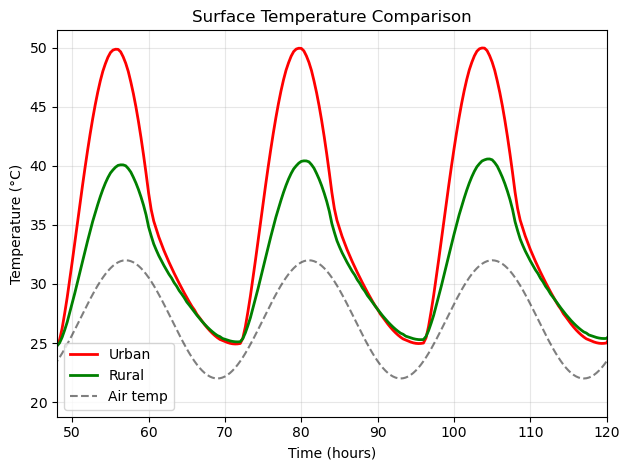

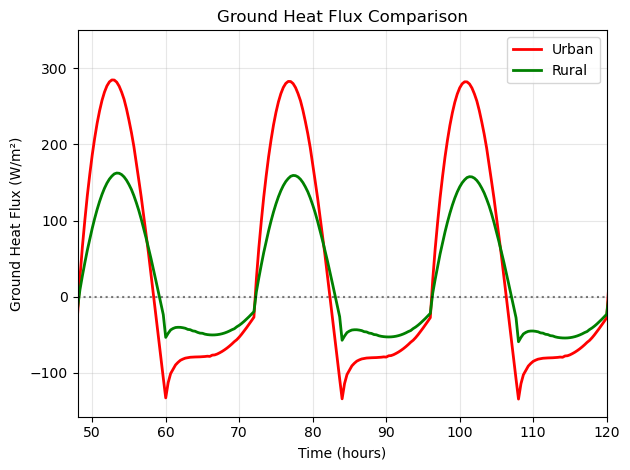

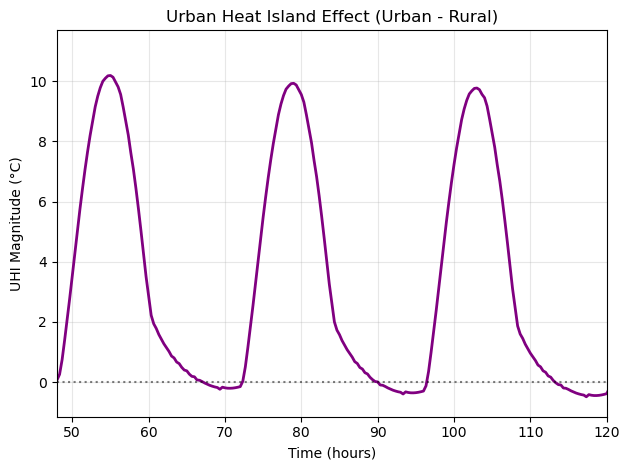

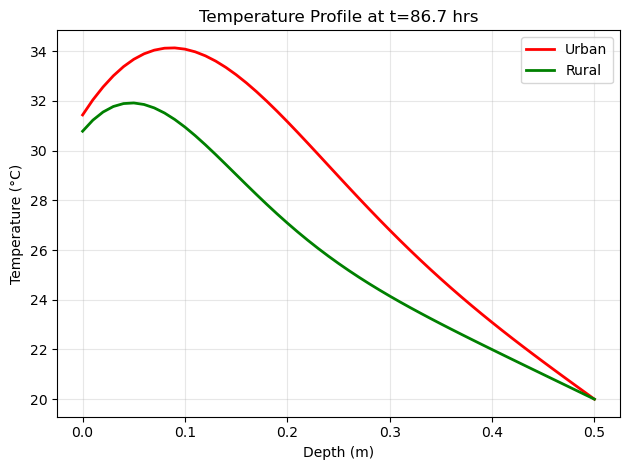


Summary (last 24 hours):
Urban surface temp: 25.0 to 50.0 °C
Rural surface temp: 25.4 to 40.7 °C
Max UHI: 9.64 °C
Min UHI: -0.56 °C
Nighttime UHI (avg midnight-6am): 4.58 °C


In [31]:
time_array_extended = np.concatenate([[0], time_array])

fig, ax = plt.subplots()
#2, 2, figsize=(15, 10)
# Surface temperatures
# ax = axes[0, 0]
ax.plot(time_array / 3600, diag_urban['T_surface'], 'r-', label='Urban', linewidth=2)
ax.plot(time_array / 3600, diag_rural['T_surface'], 'g-', label='Rural', linewidth=2)
ax.plot(time_array / 3600, T_air_series, 'k--', label='Air temp', alpha=0.5)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Surface Temperature Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([48, 120])  # Show days 2-5
plt.tight_layout()
plt.savefig("finalproj/surface_temp_comparison.pdf",transparent=True)
plt.show()

# ground heat flux
fig, ax = plt.subplots()
ax.plot(time_array / 3600, diag_urban['G'], 'r-', label='Urban', linewidth=2)
ax.plot(time_array / 3600, diag_rural['G'], 'g-', label='Rural', linewidth=2)
ax.axhline(0, color='k', linestyle=':', alpha=0.5)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Ground Heat Flux (W/m²)')
ax.set_title('Ground Heat Flux Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([48, 120])
plt.tight_layout()
plt.show()

# uhi magnitude (urban - rural surface temp)
fig, ax = plt.subplots()
UHI = diag_urban['T_surface'] - diag_rural['T_surface']
ax.plot(time_array / 3600, UHI, 'purple', linewidth=2)
ax.axhline(0, color='k', linestyle=':', alpha=0.5)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('UHI Magnitude (°C)')
ax.set_title('Urban Heat Island Effect (Urban - Rural)')
ax.grid(True, alpha=0.3)
ax.set_xlim([48, 120])
plt.tight_layout()
plt.show()

# tmep profiles at specific time 
fig, ax = plt.subplots()
idx_3pm_day3 = int((72 + 15) * 3600 / urban_params['dt']) 
ax.plot(z_urban, T_history_urban[idx_3pm_day3, :], 'r-', linewidth=2, label='Urban')
ax.plot(z_rural, T_history_rural[idx_3pm_day3, :], 'g-', linewidth=2, label='Rural')
ax.set_xlabel('Depth (m)')
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'Temperature Profile at t={time_array[idx_3pm_day3-1]/3600:.1f} hrs')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics (last 24 hours for steady-state)
last_day = n_timesteps - int(86400 / urban_params['dt'])
print(f"\nSummary (last 24 hours):")
print(f"Urban surface temp: {diag_urban['T_surface'][last_day:].min():.1f} to {diag_urban['T_surface'][last_day:].max():.1f} °C")
print(f"Rural surface temp: {diag_rural['T_surface'][last_day:].min():.1f} to {diag_rural['T_surface'][last_day:].max():.1f} °C")
print(f"Max UHI: {UHI[last_day:].max():.2f} °C")
print(f"Min UHI: {UHI[last_day:].min():.2f} °C")
print(f"Nighttime UHI (avg midnight-6am): {np.mean([UHI[i] for i in range(last_day, n_timesteps) if (time_array[i] % 86400) < 6*3600]):.2f} °C")

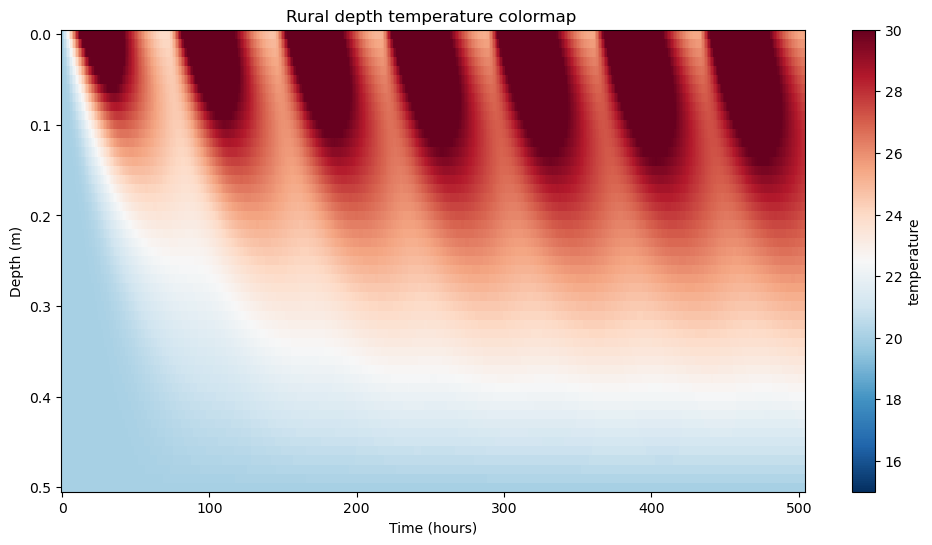

In [32]:
# transpose to make visualizing easier
X = np.array(T_history_rural).T 
time = np.arange(X.shape[1])
depth_m = np.arange(X.shape[0]) / 100

plt.figure(figsize=(12, 6))
plt.pcolormesh(time, depth_m, X, shading='auto', cmap='RdBu_r')
plt.colorbar(label='temperature')
plt.clim(15,30)
plt.xlabel('Time (hours)')
plt.ylabel('Depth (m)')
plt.gca().invert_yaxis()
plt.title('Rural depth temperature colormap ')
# plt.savefig("finalproj/rural_colormap.pdf",transparent=True)
plt.show()

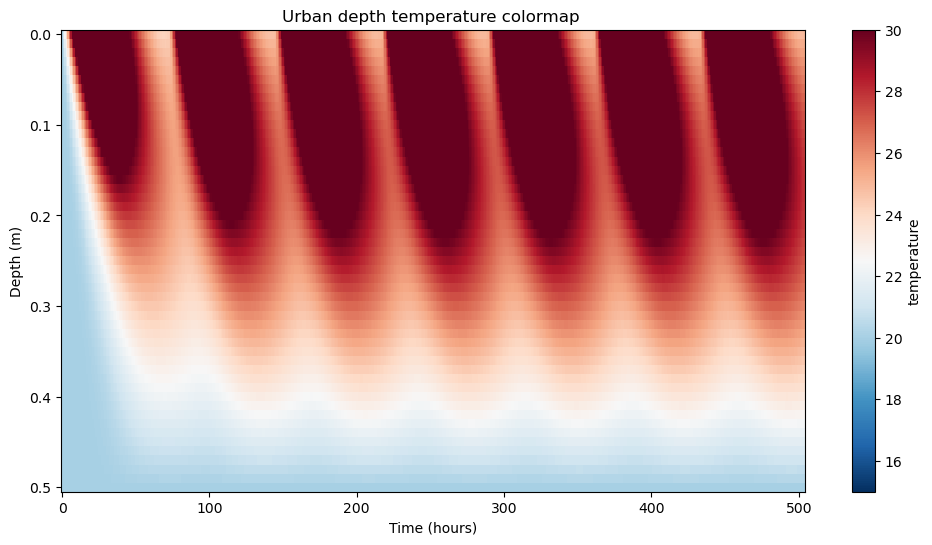

In [33]:
# transpose to make visualizing easier
X = np.array(T_history_urban).T 
time = np.arange(X.shape[1])
depth_m = np.arange(X.shape[0]) / 100

plt.figure(figsize=(12, 6))
plt.pcolormesh(time, depth_m, X, shading='auto', cmap='RdBu_r')
plt.colorbar(label='temperature')
plt.clim(15,30)
plt.xlabel('Time (hours)')
plt.ylabel('Depth (m)')
plt.gca().invert_yaxis()
plt.title('Urban depth temperature colormap ')
# plt.savefig("finalproj/urban_colormap.pdf",transparent=True)
plt.show()

The specific temperatures shown here are pretty arbitrary because of the very large number of assumptions. What's a bit more important is the difference between how the 'urban environment' and 'rural environment' react to the same solar cycle. The urban surfaces reach temperatures approximately 10 degrees warmer than the rural peak. This large difference in temperature magnitude is the UHI effect! It's a direct, physically explainable result of the combined effects of lower albedo (the surface is capable of absorbing more solar radiation), absence of evaporative cooling (the surface is losing less heat via evaporation), and additional heat from anthropogenic (human-made) sources. In general, the urban temperature profile is characterized by deeper and hotter heat penetration and smaller gaps between the pockets of heat. This makes sense given that the parameters at play here vary the surface diffusivity values between urban and rural environments. The smaller gaps and deeper penetration would, in reality, mean that the ground would tend to retain heat longer, and multiple heat events might `stack' up to worsen the effect even more. Given this model is using idealized and unchanging cycles of solar radiation and air temperature, this effect is not really shown here.

There's still significant limitations here beyond the large number of assumptions. This model is still 1-dimensional in space, and this of course is not how the real world looks. Additional mechanisms (advection, effect of buildings, etc.) also play a big role in UHI. A more physically coherent model might show the surface temperature retaining its heat longer, the differences in temperature likely wouldn't be as large, and would also be able to show spatial variation.

Even so, the model correctly captures some of the big features: urban surfaces are consistently warmer than rural throughout a 24-hour heating and cooling cycle, the difference between the environments is larger during the daytime, and UHI continues into the night because excess heat absorbed from the day is released. The model also showcases some of the mechanisms that cause this in real life; reduced albedo and evaporative cooling values increase the amount of energy absorbed in the daytime, and a higher capacity for thermal storage keeps this energy around for nighttime release.